In [1]:
import jax
import jax.numpy as jnp
# jnp.set_printoptions(precision=3, suppress=True)
import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# # set jax XLA_PYTHON_CLIENT_MEM_FRACTION=.XX
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".05"

# set jax to use the ONLY the CPU, with os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
# disable the GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

print(jax.devices())

CUDA backend failed to initialize: Unable to load CUDA. Is it installed? (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


[CpuDevice(id=0)]


In [2]:
key = jax.random.PRNGKey(0)
key, subkey = jax.random.split(key)
w = jax.random.normal(subkey, (2, 2))
w = jnp.ones_like(w)
key, subkey = jax.random.split(key)
p = jnp.round(jax.random.uniform(subkey, (2, 2), minval=0.0, maxval=1.0) * 10,0)
s = jnp.ones_like(p) * 0.001

In [3]:
print("w\n", w)
print("p\n", p)
print("s\n", s)

w
 [[1. 1.]
 [1. 1.]]
p
 [[5. 8.]
 [9. 4.]]
s
 [[0.001 0.001]
 [0.001 0.001]]


In [4]:
w_3d = w[:, :, None]
p_3d = p[:, :, None]
s_3d = s[:, :, None]

In [5]:
def gaussian_interpolation(w, p, s, kernel_size):
    # Create a range of kernel positions: shape (kernel_size,)
    k = jnp.arange(kernel_size)
    return w * jnp.exp(- (p - k)**2 / (2 * s**2))

print("gaussian_interpolation(w, p, s, 3)\n", gaussian_interpolation(w_3d, p_3d, s_3d, 10))

gaussian_interpolation(w, p, s, 3)
 [[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]

 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
  [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]]


In [6]:
key = jax.random.PRNGKey(0)
key, subkey = jax.random.split(key)
w = jax.random.normal(subkey, (1, 2))
w = jnp.ones_like(w)
key, subkey = jax.random.split(key)
p = jnp.round(jax.random.uniform(subkey, (2,), minval=0.0, maxval=1.0) * 10, 0)
s = jnp.ones_like(p) * 0.001

In [7]:
w = w.squeeze()
w_2d = w[:, None]
p_2d = p[:, None]
s_2d = s[:, None]
print("w\n", w)
print("p\n", p)
print("s\n", s)

w
 [1. 1.]
p
 [5. 5.]
s
 [0.001 0.001]


In [8]:
print("gaussian_interpolation(w, p, s, 3)\n", gaussian_interpolation(w_2d, p_2d, s_2d, 10))

gaussian_interpolation(w, p, s, 3)
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


In [1]:
import jax 
import jax.numpy as jnp
from flax import linen as nn
from flax.core import freeze, unfreeze
import numpy as np
jnp.set_printoptions(precision=1, suppress=True, linewidth=10000)

## Synaptic, 2 inputs, 4 kernels, 2 outputs

In [4]:
import sys
sys.path.append("..")
from model import DCLSLayer
from model import construct_kernel_fast
N_LAYERS = 1
DELAY_TYPE = "synaptic"
KERNEL_SIZE = 16
INIT_STD = 0.7
N_IN = 2
N_OUT = 2
KERNEL_N_ELEMS = 4
HETEROGENEOUS_WEIGHTS = False
HETEROGENEOUS_POSITIONS = False
model = DCLSLayer(
    kernel_size=KERNEL_SIZE,
    dim_in=N_IN,
    dim_out=N_OUT,
    kernel_n_elems=KERNEL_N_ELEMS,
    fft=False,
    delay_type=DELAY_TYPE,
    delay_kernel="gaussian",
    init_std=INIT_STD,
    heterogeneous_weights=HETEROGENEOUS_WEIGHTS, 
    heterogeneous_positions=HETEROGENEOUS_POSITIONS
)

/home/tristan/Den-minGRU/notebooks/../model.py:43: SyntaxWarning: invalid escape sequence '\s'
  '''
/home/tristan/Den-minGRU/notebooks/../model.py:80: SyntaxWarning: invalid escape sequence '\s'
  '''
/home/tristan/Den-minGRU/notebooks/../model.py:451: SyntaxWarning: invalid escape sequence '\s'
  '''


In [5]:
# Create a random key
key = jax.random.PRNGKey(0)

# Create a dummy input with the appropriate shape
# Assuming the input shape is [batch_size, sequence_length, dim_in]
dummy_input = jnp.zeros((10, model.dim_in))

# Initialize the model
params = model.init(key, dummy_input)['params']

# Print the initialized parameters
print("Initialized parameters:", jax.tree_util.tree_map(lambda x: x.shape, params))
print(params)

Initialized parameters: {'positions': (4, 2, 2), 'std': (4, 2, 2), 'weights': (4, 2, 2)}
{'weights': Array([[[1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.]]], dtype=float32), 'positions': Array([[[ 0.,  0.],
        [ 0.,  0.]],

       [[ 4.,  4.],
        [ 4.,  4.]],

       [[ 8.,  8.],
        [ 8.,  8.]],

       [[12., 12.],
        [12., 12.]]], dtype=float32), 'std': Array([[[0.7, 0.7],
        [0.7, 0.7]],

       [[0.7, 0.7],
        [0.7, 0.7]],

       [[0.7, 0.7],
        [0.7, 0.7]],

       [[0.7, 0.7],
        [0.7, 0.7]]], dtype=float32)}


In [6]:
dummy_input = dummy_input.at[0, 0].set(1.0)
dummy_input = dummy_input.at[2, 1].set(1.0)
print(f'{dummy_input}')

[[1. 0.]
 [0. 0.]
 [0. 1.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


In [56]:
output = model.apply({'params': params}, dummy_input)
print("Output shape:", output.shape)   # [1, 19, 2]
print(f"{output}")

(3, 2, 2)
(3, 2, 2)
(3, 2, 2)
(3, 2, 2)
(3, 2, 2)
(3, 2, 2)
(3, 2, 2)
(3, 2, 2)
(3, 2, 2)
Output shape: (10, 2)
[[0.  0. ]
 [0.8 0. ]
 [1.3 0. ]
 [1.9 0.4]
 [1.3 1. ]
 [1.2 0.5]
 [1.2 1.6]
 [0.6 1.5]
 [0.1 0.4]
 [0.7 1.3]]


In [57]:
import matplotlib.pyplot as plt
PX = 1 / plt.rcParams['figure.dpi']  # pixel per point in the figure

In [58]:
def get_kernels(params, n_dim, kernel_size):
    ks = []
    all_k = []
    for i in range(N_LAYERS):
        w = params['weights']
        p = params['positions']
        s = params['std']
        ks_individual = []
        for j in range(w.shape[0]):
            if j == 0:
                k = construct_kernel_fast(w[j], p[j], s[j], kernel_size, n_dim)
                ks_individual.append(k)
            else:
                k_j = construct_kernel_fast(w[j], p[j], s[j], kernel_size, n_dim)
                ks_individual.append(k_j)
                k += k_j

        ks.append(k)
        all_k.append(ks_individual)
    return ks, all_k


In [59]:
n_dim = 3 if DELAY_TYPE == 'synaptic' else 2
ks_init, all_k_init = get_kernels(params, n_dim, KERNEL_SIZE)


In [60]:
print(ks_init)

[Array([[[0. , 0. , 0.1, 0.6, 0.9, 0.2, 0.2, 1. , 1.3, 0.8],
        [0. , 0.1, 0.8, 0.7, 0.1, 0. , 0.3, 1.1, 1.1, 0.9]],

       [[0.6, 0.9, 0.4, 1.5, 1.6, 0.2, 0. , 0. , 0. , 0. ],
        [0.4, 1.3, 1.3, 0.4, 0. , 0. , 0. , 0.3, 1. , 0.4]]], dtype=float32)]


In [61]:
for i in range(len(all_k_init[0])):
    print(i)
    print(all_k_init[0][i])

0
[[[0.  0.  0.  0.  0.  0.  0.2 0.9 0.6 0. ]
  [0.  0.  0.  0.  0.  0.  0.3 1.  0.4 0. ]]

 [[0.6 0.9 0.2 0.  0.  0.  0.  0.  0.  0. ]
  [0.4 1.  0.3 0.  0.  0.  0.  0.  0.  0. ]]]
1
[[[0.  0.  0.1 0.6 0.9 0.2 0.  0.  0.  0. ]
  [0.  0.1 0.8 0.7 0.1 0.  0.  0.  0.  0. ]]

 [[0.  0.  0.1 0.8 0.7 0.1 0.  0.  0.  0. ]
  [0.  0.3 1.  0.4 0.  0.  0.  0.  0.  0. ]]]
2
[[[0.  0.  0.  0.  0.  0.  0.  0.1 0.7 0.8]
  [0.  0.  0.  0.  0.  0.  0.  0.1 0.7 0.8]]

 [[0.  0.  0.1 0.7 0.9 0.2 0.  0.  0.  0. ]
  [0.  0.  0.  0.  0.  0.  0.  0.3 1.  0.4]]]


In [7]:
def plot_kernels_axonal(ks):
    PX = 1 / plt.rcParams['figure.dpi']
    fig, axes = plt.subplots(N_LAYERS, 1, figsize=(600*PX, 600 * PX * N_LAYERS), constrained_layout=True)

    for i in range(N_LAYERS):
        max_val = np.max(np.abs(ks[i]))
        ax = axes[i] if N_LAYERS > 1 else axes  # Handle single subplot case
        im = ax.matshow(ks[i], cmap='RdBu_r', vmin=-max_val, vmax=max_val)
        ax.set_title(f"Visualization of ks[{i}]")
        ax.set_yticks(np.arange(ks[i].shape[0]))

    fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    plt.show()


In [8]:
def plot_kernels_syn(ks):
    PX = 1 / plt.rcParams['figure.dpi']
    fig, axes = plt.subplots(1, N_LAYERS, figsize=(1000*PX, 1500 * PX * N_LAYERS), constrained_layout=True)

    for i in range(N_LAYERS):
        max_val = np.max(np.abs(ks[i]))
        ax = axes[i] if N_LAYERS > 1 else axes  # Handle single subplot case
        im = ax.matshow(ks[i].reshape(ks[i].shape[0]*ks[i].shape[1], ks[i].shape[2]), cmap='RdBu_r', vmin=-max_val, vmax=max_val)
        ax.set_title(f"Visualization of ks[{i}]")
        yticks_labels = np.arange(ks[i].shape[0]).repeat(ks[i].shape[1])
        ax.set_yticks(np.arange(0, ks[i].shape[0]*ks[i].shape[1], 1))
        ax.set_yticklabels(yticks_labels)

    fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    plt.show()


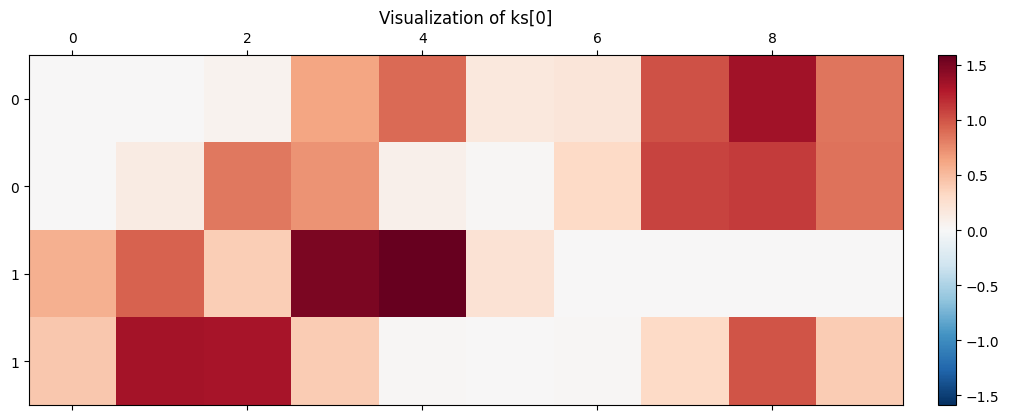

In [64]:
if DELAY_TYPE == 'axonal':
    plot_kernels_axonal(ks_init)
else:
    plot_kernels_syn(ks_init)

## Axonal: 2 inputs, 2 kernels, 2 outputs

In [9]:
from model import DCLSLayer
from model import construct_kernel_fast
N_LAYERS = 1
DELAY_TYPE = "axonal"
KERNEL_SIZE = 64
INIT_STD = 0.7
N_IN = 2
N_OUT = 2
KERNEL_N_ELEMS = 8
HETEROGENEOUS_WEIGHTS = False
HETEROGENEOUS_POSITIONS = False
model = DCLSLayer(
    kernel_size=KERNEL_SIZE,
    dim_in=N_IN,
    dim_out=N_OUT,
    kernel_n_elems=KERNEL_N_ELEMS,
    fft=False,
    delay_type=DELAY_TYPE,
    delay_kernel="gaussian",
    init_std=INIT_STD,
    heterogeneous_weights=HETEROGENEOUS_WEIGHTS, 
    heterogeneous_positions=HETEROGENEOUS_POSITIONS
)

In [10]:
# Create a random key
key = jax.random.PRNGKey(0)

# Create a dummy input with the appropriate shape
# Assuming the input shape is [batch_size, sequence_length, dim_in]
dummy_input = jnp.zeros((10, model.dim_in))

# Initialize the model
params = model.init(key, dummy_input)['params']

# Print the initialized parameters
print("Initialized parameters:", jax.tree_util.tree_map(lambda x: x.shape, params))
print(params)

Initialized parameters: {'positions': (8, 2), 'std': (8, 2), 'weights': (8, 2)}
{'weights': Array([[1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.]], dtype=float32), 'positions': Array([[ 0.,  0.],
       [ 8.,  8.],
       [16., 16.],
       [24., 24.],
       [32., 32.],
       [40., 40.],
       [48., 48.],
       [56., 56.]], dtype=float32), 'std': Array([[0.7, 0.7],
       [0.7, 0.7],
       [0.7, 0.7],
       [0.7, 0.7],
       [0.7, 0.7],
       [0.7, 0.7],
       [0.7, 0.7],
       [0.7, 0.7]], dtype=float32)}


In [10]:
dummy_input = dummy_input.at[0, 0].set(1.0)
dummy_input = dummy_input.at[2, 1].set(1.0)
print(f'{dummy_input}')

[[1. 0.]
 [0. 0.]
 [0. 1.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


In [11]:
output = model.apply({'params': params}, dummy_input)
print("Output shape:", output.shape)   # [1, 19, 2]
print(f"{output}")

Output shape: (10, 2)
[[0.  0. ]
 [1.  0. ]
 [0.4 0. ]
 [0.  1. ]
 [0.  0.4]
 [0.  0. ]
 [0.  0. ]
 [0.  0. ]
 [0.4 0. ]
 [1.  0. ]]


In [12]:
import matplotlib.pyplot as plt
PX = 1 / plt.rcParams['figure.dpi']  # pixel per point in the figure

In [13]:
def get_kernels(params, n_dim, kernel_size):
    ks = []
    all_k = []
    for i in range(N_LAYERS):
        w = params['weights']
        p = params['positions']
        s = params['std']
        ks_individual = []
        for j in range(w.shape[0]):
            if j == 0:
                k = construct_kernel_fast(w[j], p[j], s[j], kernel_size, n_dim)
                ks_individual.append(k)
            else:
                k_j = construct_kernel_fast(w[j], p[j], s[j], kernel_size, n_dim)
                ks_individual.append(k_j)
                k += k_j

        ks.append(k)
        all_k.append(ks_individual)
    return ks, all_k


In [14]:
n_dim = 3 if DELAY_TYPE == 'synaptic' else 2
ks_init, all_k_init = get_kernels(params, n_dim, KERNEL_SIZE)


In [15]:
print(ks_init)

[Array([[0. , 0. , 0. , 0. , 0. , 0. , 0.4, 1. , 0.4, 0. , 0. , 0. , 0. , 0. , 0.4, 1. , 0.4, 0. , 0. , 0. , 0. , 0. , 0.4, 1. , 0.4, 0. , 0. , 0. , 0. , 0. , 0.4, 1. , 0.4, 0. , 0. , 0. , 0. , 0. , 0.4, 1. , 0.4, 0. , 0. , 0. , 0. , 0. , 0.4, 1. , 0.4, 0. , 0. , 0. , 0. , 0. , 0.4, 1. , 0.4, 0. , 0. , 0. , 0. , 0. , 0.4, 1. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0.4, 1. , 0.4, 0. , 0. , 0. , 0. , 0. , 0.4, 1. , 0.4, 0. , 0. , 0. , 0. , 0. , 0.4, 1. , 0.4, 0. , 0. , 0. , 0. , 0. , 0.4, 1. , 0.4, 0. , 0. , 0. , 0. , 0. , 0.4, 1. , 0.4, 0. , 0. , 0. , 0. , 0. , 0.4, 1. , 0.4, 0. , 0. , 0. , 0. , 0. , 0.4, 1. , 0.4, 0. , 0. , 0. , 0. , 0. , 0.4, 1. ]], dtype=float32)]


In [16]:
for i in range(len(all_k_init[0])):
    print(all_k_init[0][i])

[[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.4 1. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.4 1. ]]
[[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.4 1.  0.4 0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.4 

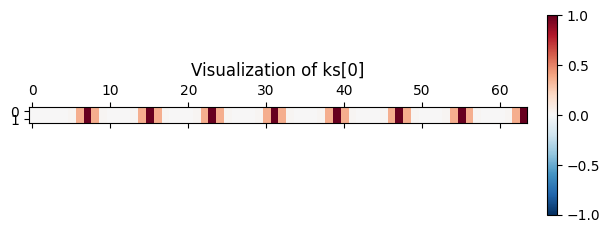

In [20]:
if DELAY_TYPE == 'axonal':
    plot_kernels_axonal(ks_init)
else:
    plot_kernels_syn(ks_init)